In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,VotingClassifier,BaggingClassifier

In [21]:
data = pd.read_csv("diabetes.csv")

In [22]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [23]:
data.shape

(768, 9)

In [24]:
data.columns.tolist()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [25]:
Num_col = [col for col in data.columns if data[col].dtypes != "object"]

In [26]:
Num_col

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [27]:
Cat_col = [col for col in data.columns if data[col].dtypes == "object"]

In [28]:
Cat_col

[]

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [30]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [31]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

In [32]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [33]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [34]:
data.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

## EDA Analysis

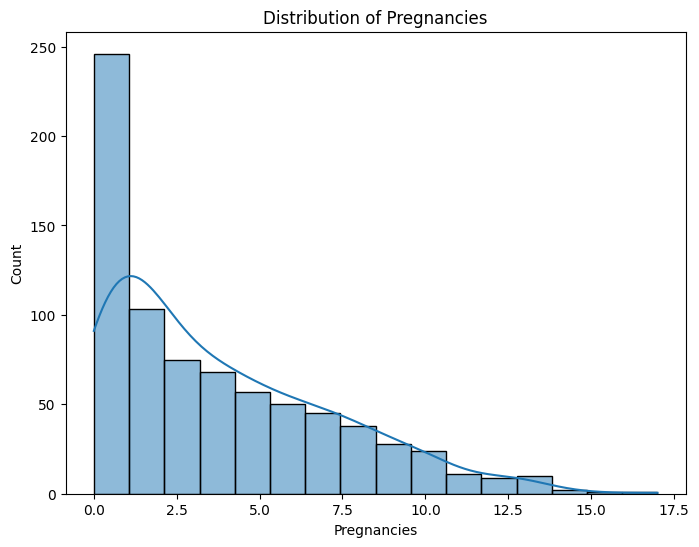

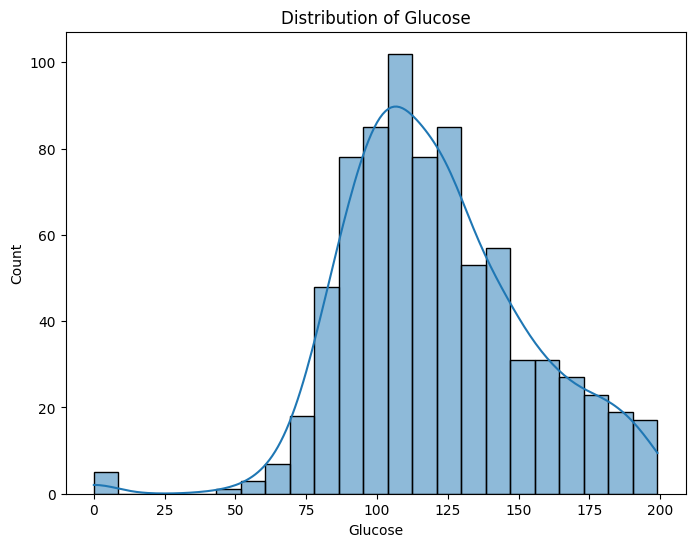

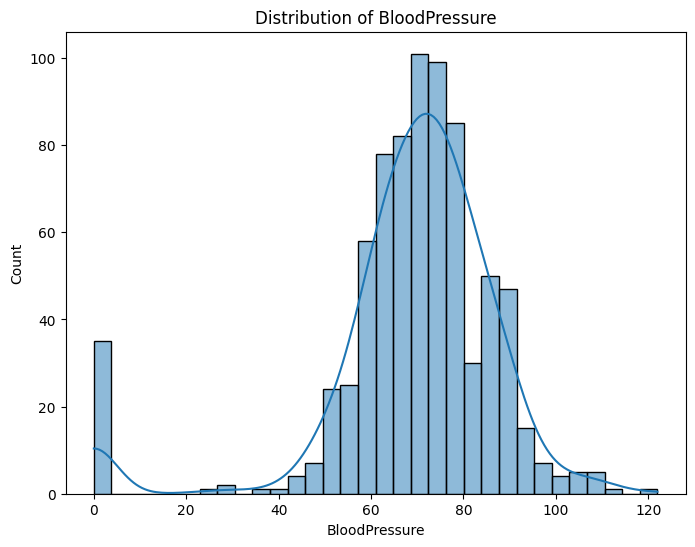

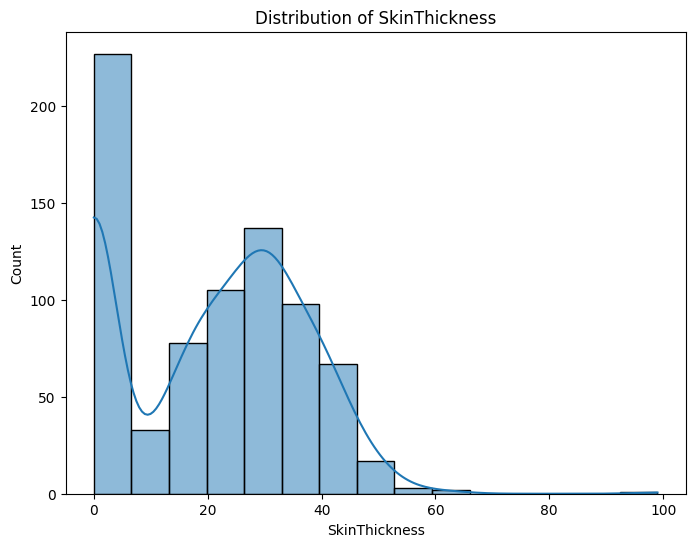

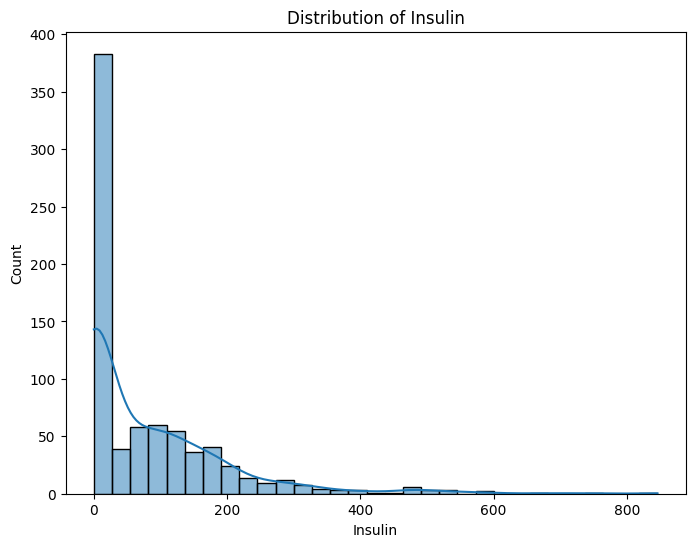

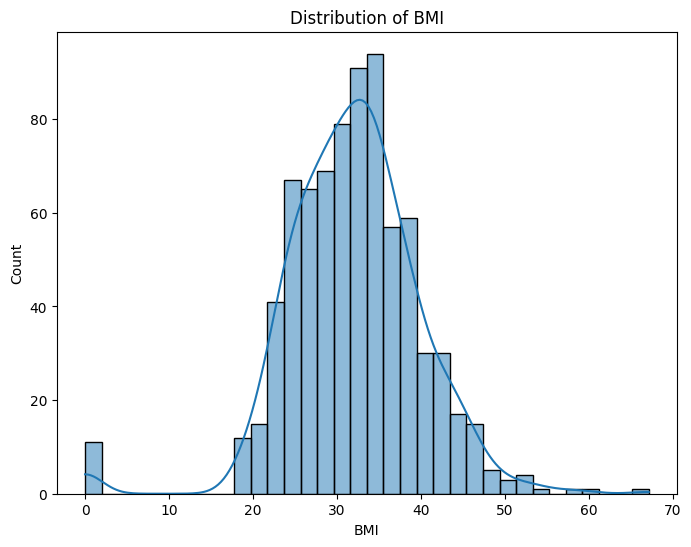

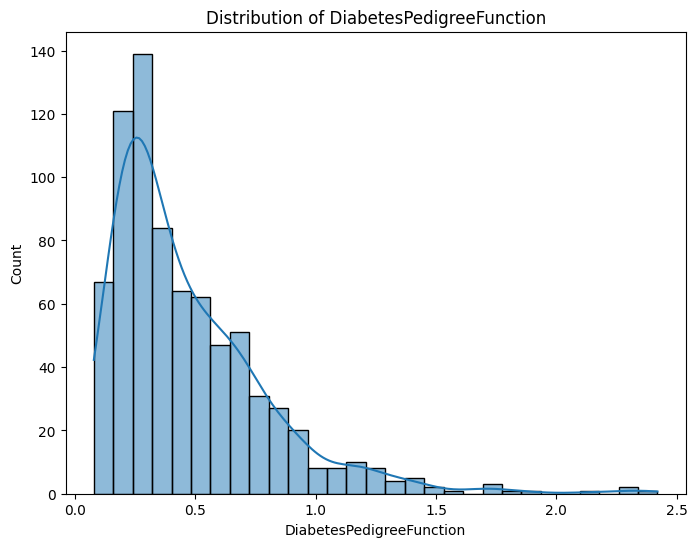

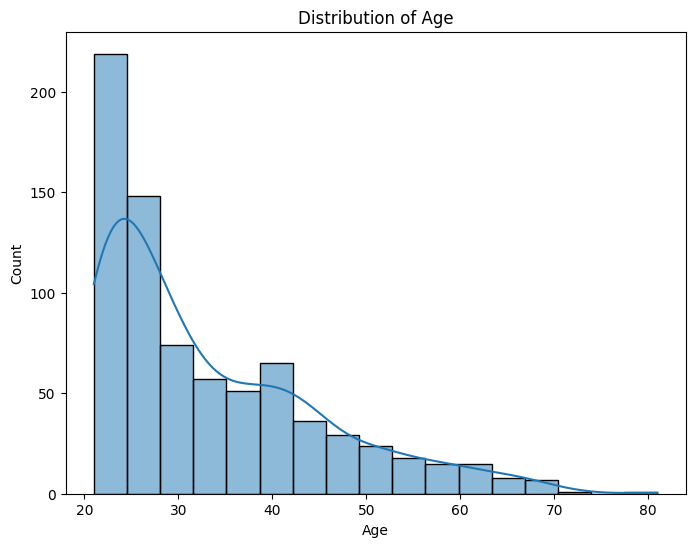

In [35]:
for col in data.columns[:-1]:
    plt.figure(figsize = (8,6))
    sns.histplot(data[col],kde = True)
    plt.title(f"Distribution of {col}")
    plt.show()

##  Pie chart

C:\Users\Dell\AppData\Local\Temp\ipykernel_9428\1675217651.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


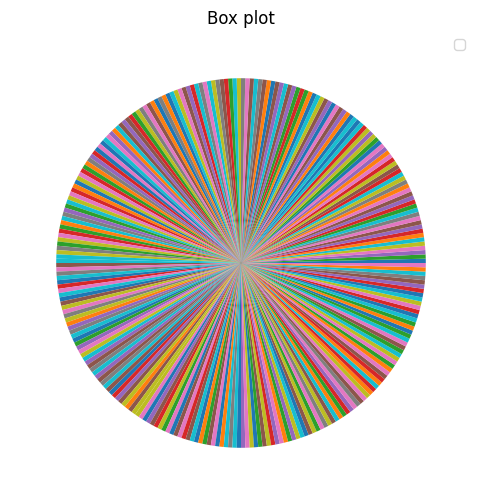

In [45]:
plt.figure(figsize=(8,6))
plt.pie(data["Outcome"])
plt.title("Box plot")
plt.legend()
plt.show()

In [91]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [92]:
mean_bp = np.mean(data.loc[data["BloodPressure"] > 0,'BloodPressure'])

In [93]:
data["BloodPressure"] = data["BloodPressure"].replace(0,mean_bp)

In [94]:
if 0 in data["BloodPressure"].values:
    print("0 is present")
else:
    print("no present")

no present


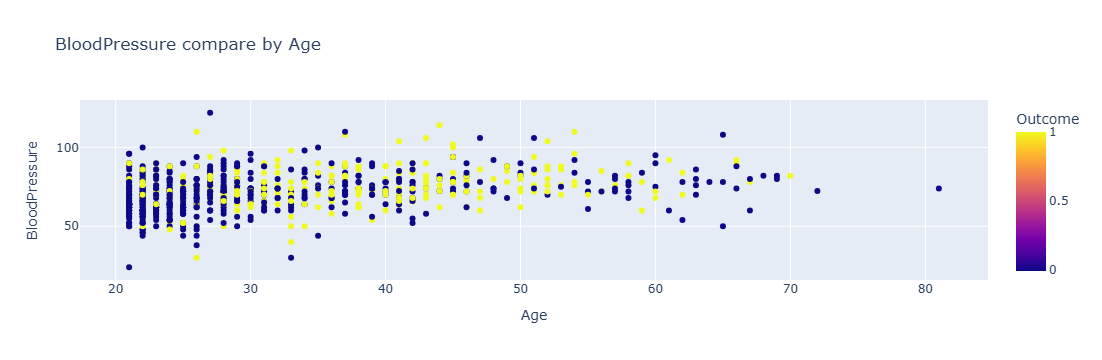

In [95]:
fig = px.scatter(data,x=data["Age"],y=data["BloodPressure"],hover_name=data["Outcome"].astype(str) +" - "+ data["Glucose"].astype(str),
                 color = data["Outcome"],color_discrete_sequence=["Pink","Red"],title="BloodPressure compare by Age")
fig.show()

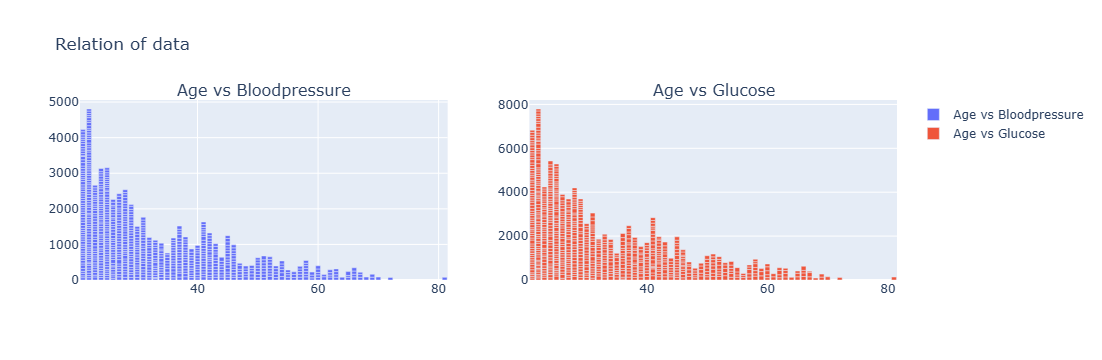

In [100]:
fig1 = make_subplots(rows=1,cols=2,subplot_titles=("Age vs Bloodpressure","Age vs Glucose"))

fig1.add_trace(go.Bar(x=data["Age"],y=data["BloodPressure"],name="Age vs Bloodpressure"),row=1,col=1)
fig1.add_trace(go.Bar(x=data["Age"],y=data["Glucose"],name="Age vs Glucose"),row=1,col=2)

fig1.update_layout(title="Relation of data",
                  xaxis= dict(showgrid=True),
                  yaxis=dict(showgrid=True),
                  showlegend=True
                  )

fig1.show()
               


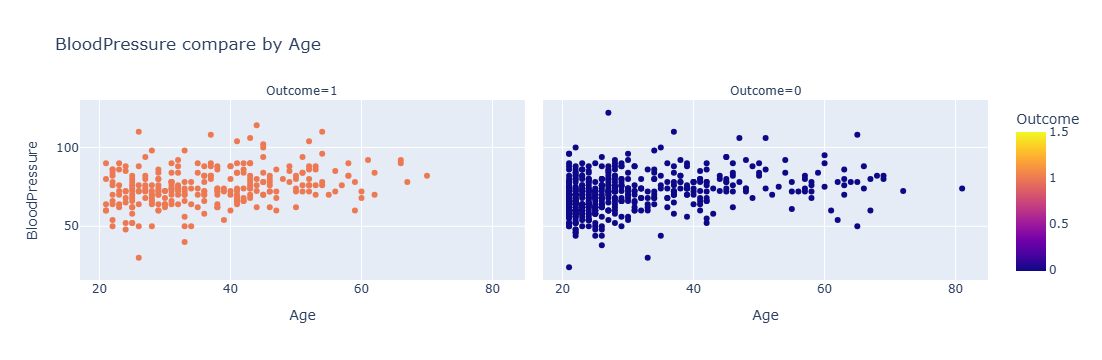

In [104]:
fig2 = px.scatter(data,x=data["Age"],y=data["BloodPressure"],hover_name=data["Outcome"].astype(str) +" - "+ data["Glucose"].astype(str),
                 color = data["Outcome"],
                  facet_col=data["Outcome"],title="BloodPressure compare by Age")
fig2.show()

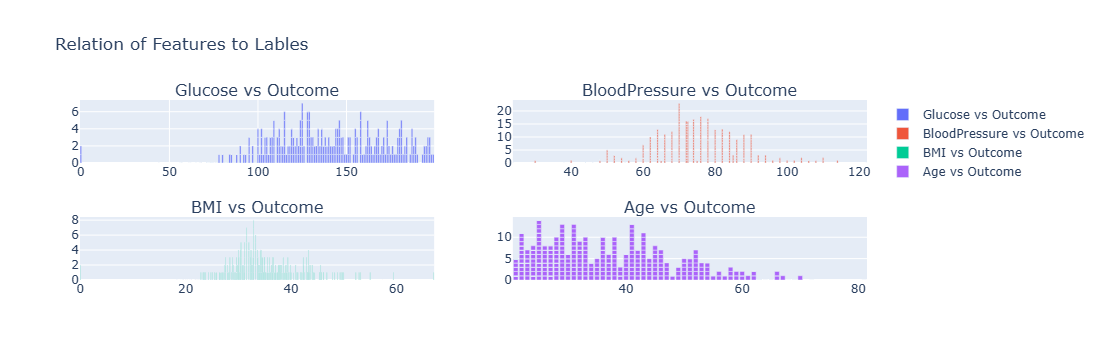

In [131]:
figNew = make_subplots(rows=2,cols=2,subplot_titles=('Glucose vs Outcome','BloodPressure vs Outcome', 'BMI vs Outcome','Age vs Outcome'),
                      vertical_spacing=0.3,horizontal_spacing=0.1)

figNew.add_trace(go.Bar(x=data['Glucose'],y=data['Outcome'],name='Glucose vs Outcome'),row=1,col=1)
figNew.add_trace(go.Bar(x=data['BloodPressure'],y=data['Outcome'],name='BloodPressure vs Outcome'),row=1,col=2)
figNew.add_trace(go.Bar(x=data['BMI'],y=data['Outcome'],name='BMI vs Outcome'),row=2,col=1)
figNew.add_trace(go.Bar(x=data['Age'],y=data['Outcome'],name='Age vs Outcome'),row=2,col=2)

figNew.update_layout(title="Relation of Features to Lables",
                  xaxis= dict(showgrid=True),
                  yaxis=dict(showgrid=True),
                  showlegend=True
                  )

figNew.show()

<Figure size 2000x2000 with 0 Axes>

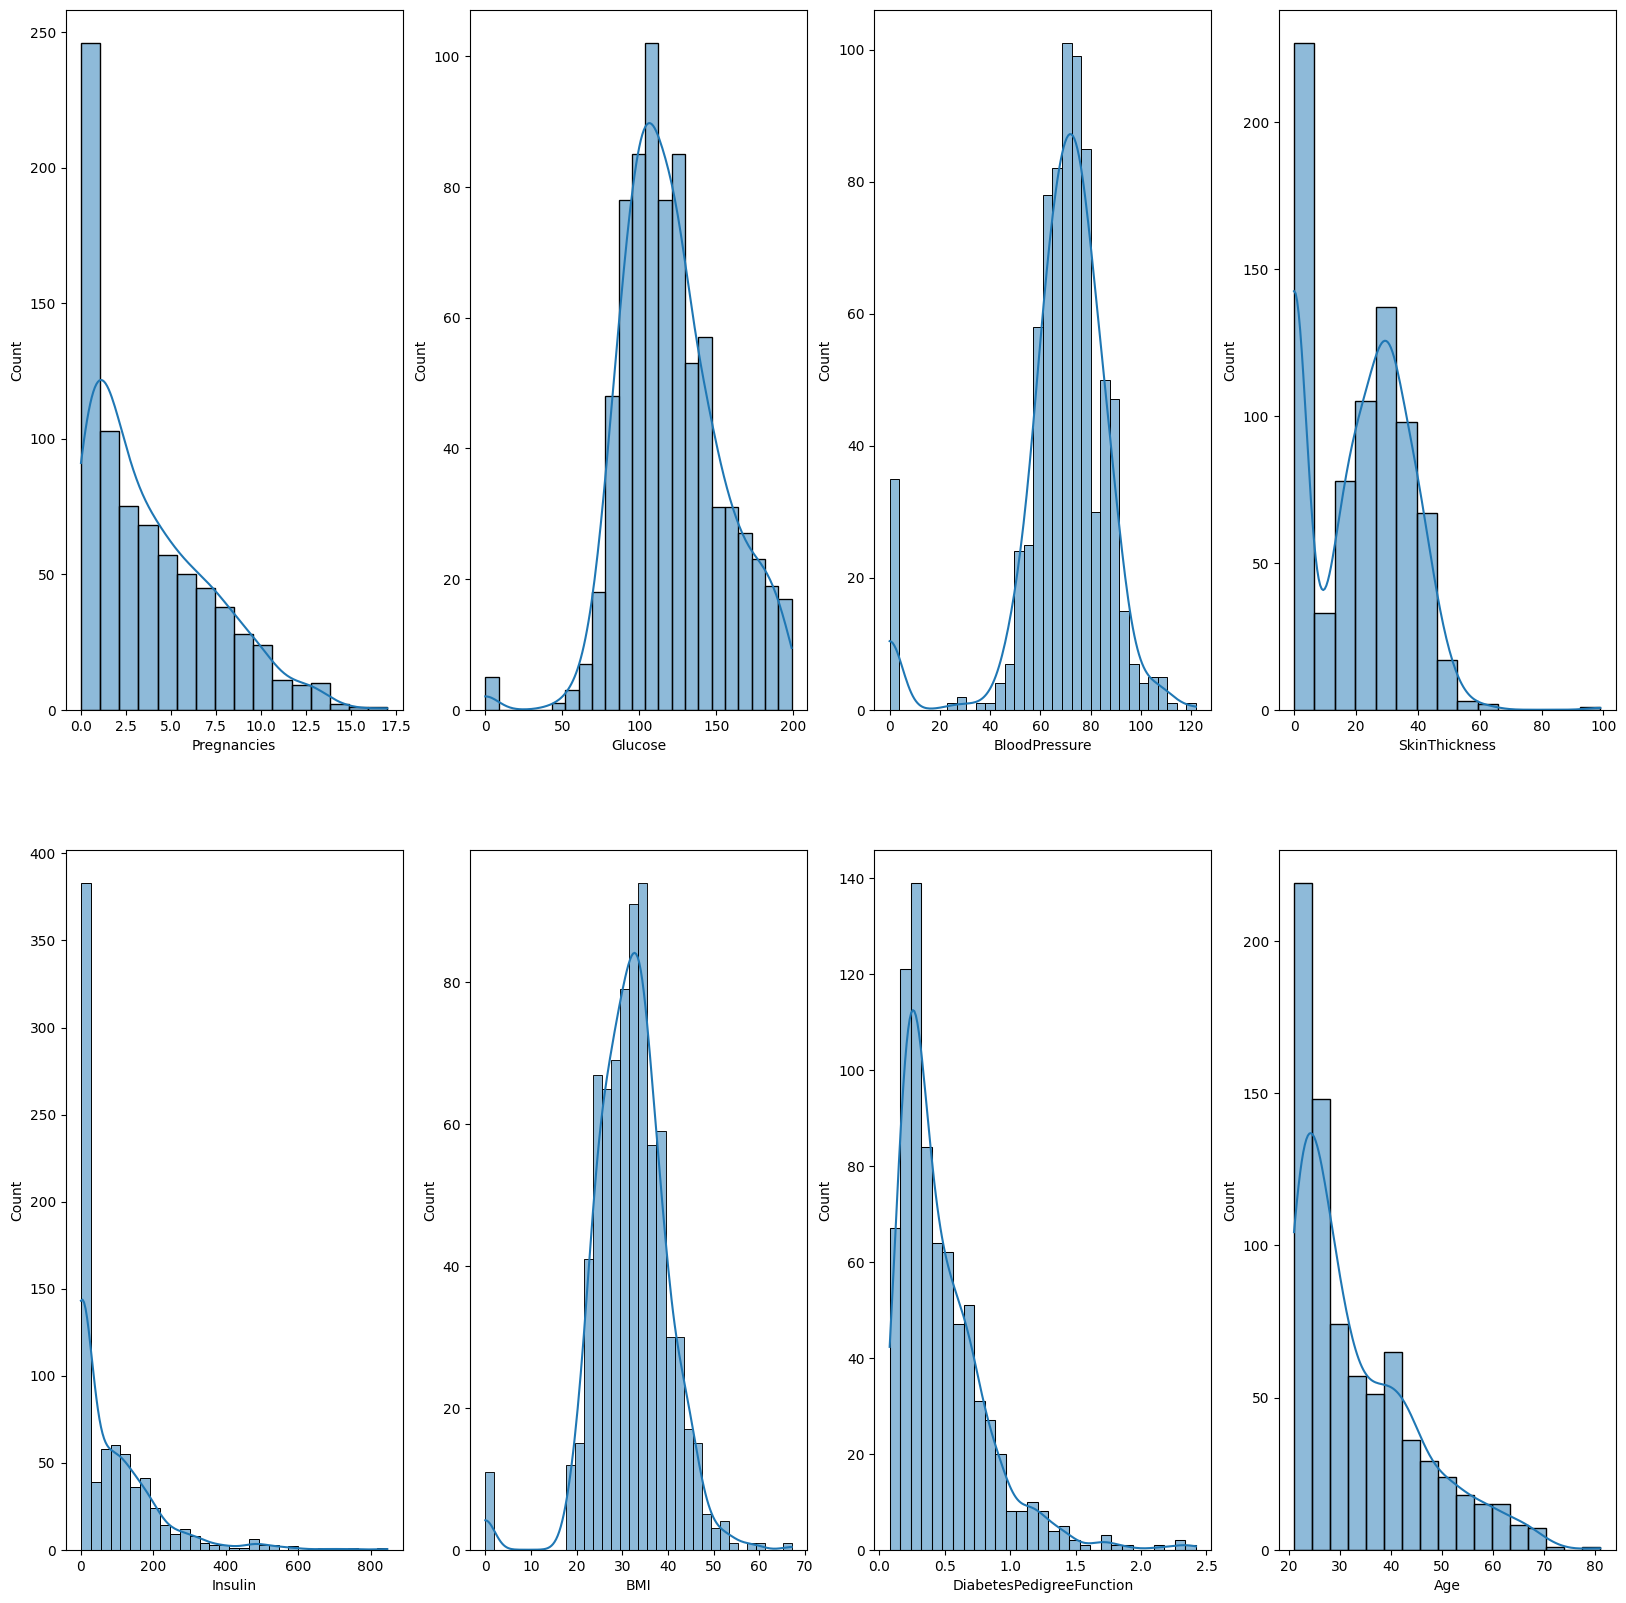

In [17]:
plt.figure(figsize = (20,20))
fig ,ax = plt.subplots(2,4,figsize = (20,20))
sns.histplot(x="Pregnancies",data=data,kde=True,ax=ax[0,0])
sns.histplot(x="Glucose",data=data,kde=True,ax=ax[0,1])
sns.histplot(x="BloodPressure",data=data,kde=True,ax=ax[0,2])
sns.histplot(x="SkinThickness",data=data,kde=True,ax=ax[0,3])
sns.histplot(x="Insulin",data=data,kde=True,ax=ax[1,0])
sns.histplot(x="BMI",data=data,kde=True,ax=ax[1,1])
sns.histplot(x="DiabetesPedigreeFunction",data=data,kde=True,ax=ax[1,2])
sns.histplot(x="Age",data=data,kde=True,ax=ax[1,3])
plt.show()


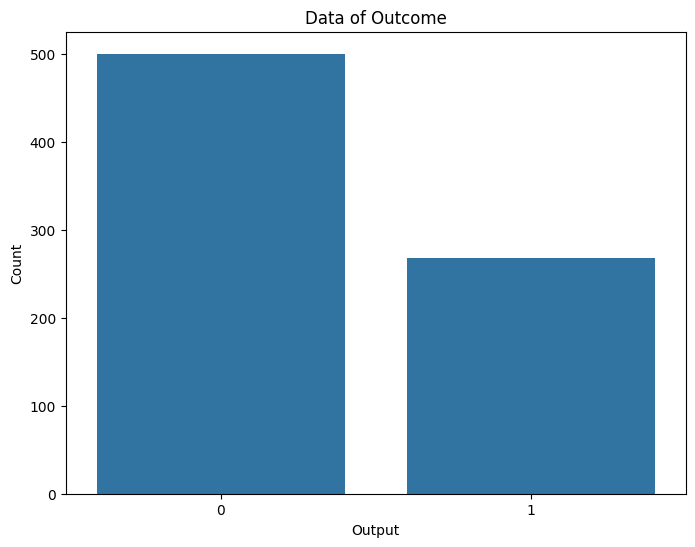

In [18]:
plt.figure(figsize=(8,6))
sns.countplot(x="Outcome",data=data)
plt.title("Data of Outcome")
plt.xlabel("Output")
plt.ylabel("Count")
plt.show()

In [20]:
data1 = data.drop("Outcome",axis=1)

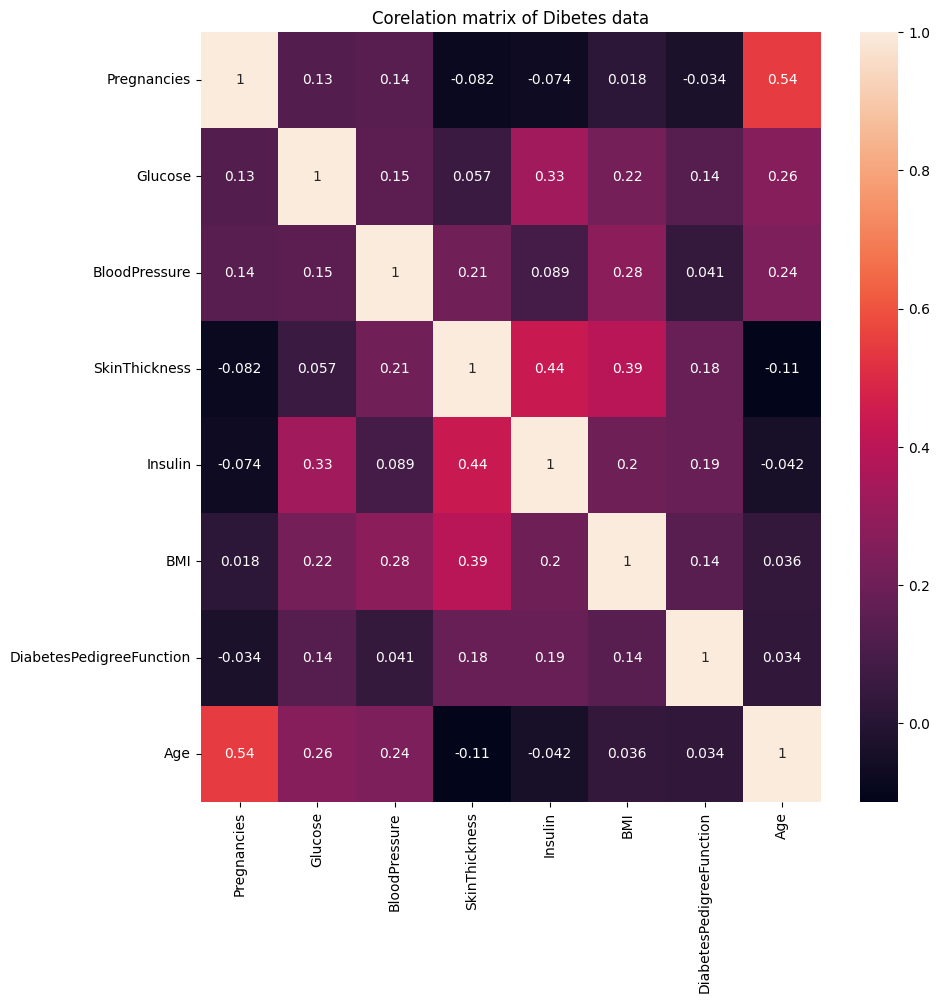

In [21]:
plt.figure(figsize=(10,10))
sns.heatmap(data1.corr(),annot=True,color="Blue")
plt.title("Corelation matrix of Dibetes data")
plt.show()

In [22]:
x = data.drop("Outcome",axis=1)
y = data["Outcome"]

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10)

## Decesion Tree

In [24]:
modelDT = DecisionTreeClassifier()

In [25]:
modelDT.fit(x_train,y_train)

DecisionTreeClassifier()

In [26]:
train_pred = modelDT.predict(x_train) 

In [32]:
accuracy_score(train_pred,y_train)

1.0

## KNeighborsClassifier

In [33]:
modelKNN = KNeighborsClassifier(n_neighbors=3)

In [34]:
scale = StandardScaler()

In [35]:
x_scale = scale.fit_transform(x_train)

In [36]:
modelKNN.fit(x_scale,y_train)

KNeighborsClassifier(n_neighbors=3)

In [37]:
train_pred = modelKNN.predict(x_scale)

In [38]:
accuracy_score(train_pred,y_train)

0.8664495114006515

## Logistics Regression

In [39]:
modelLR = LogisticRegression(max_iter=200)

In [40]:
scale = StandardScaler()

In [41]:
x_scale = scale.fit_transform(x_train)

In [42]:
modelLR.fit(x_scale,y_train)

LogisticRegression(max_iter=200)

In [43]:
train_pred = modelLR.predict(x_scale)

In [44]:
accuracy_score(y_train,train_pred)

0.7736156351791531

## SVM

In [45]:
modelSVM = SVC()

In [46]:
scale = StandardScaler()

In [47]:
x_scale = scale.fit_transform(x_train)

In [48]:
modelSVM.fit(x_scale,y_train)

SVC()

In [49]:
train_perd = modelSVM.predict(x_scale)

In [50]:
accuracy_score(train_pred,y_train)

0.7736156351791531

## Random Forest Classifier

In [51]:
modelRF = RandomForestClassifier(n_estimators = 100)

In [52]:
modelRF.fit(x_train,y_train)

RandomForestClassifier()

In [53]:
train_pred = modelRF.predict(x_train)

In [54]:
accuracy_score(train_pred,y_train)

1.0

## Now We check accuracy of Testing data on dataset

## Decesion Tree

In [55]:
test_pred = modelDT.predict(x_test)

In [56]:
accuracy_score(test_pred,y_test)

0.7142857142857143

In [57]:
confusion_matrix(test_pred,y_test)

array([[77, 26],
       [18, 33]], dtype=int64)

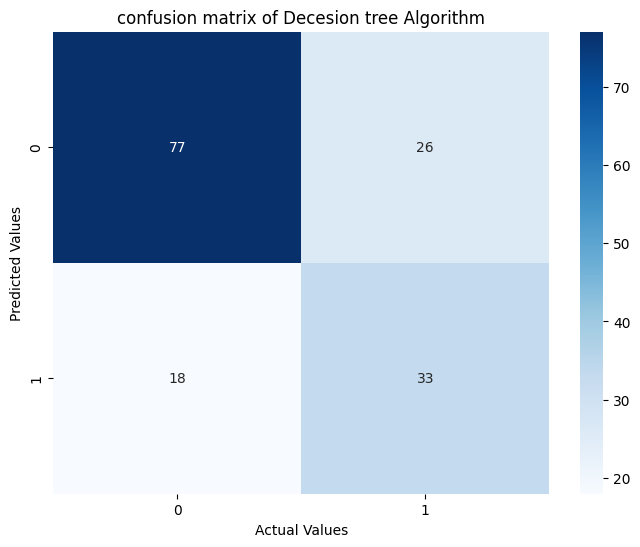

In [58]:
plt.figure(figsize = (8,6))
sns.heatmap(confusion_matrix(test_pred,y_test),annot=True,cmap="Blues")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("confusion matrix of Decesion tree Algorithm")
plt.show()

## K-Neighbors

In [59]:
scale = StandardScaler()

In [60]:
x_test_scale = scale.fit_transform(x_test)

In [61]:
test_pred = modelKNN.predict(x_test_scale)

In [62]:
accuracy_score(test_pred,y_test)

0.7272727272727273

In [63]:
confusion_matrix(test_pred,y_test)

array([[80, 27],
       [15, 32]], dtype=int64)

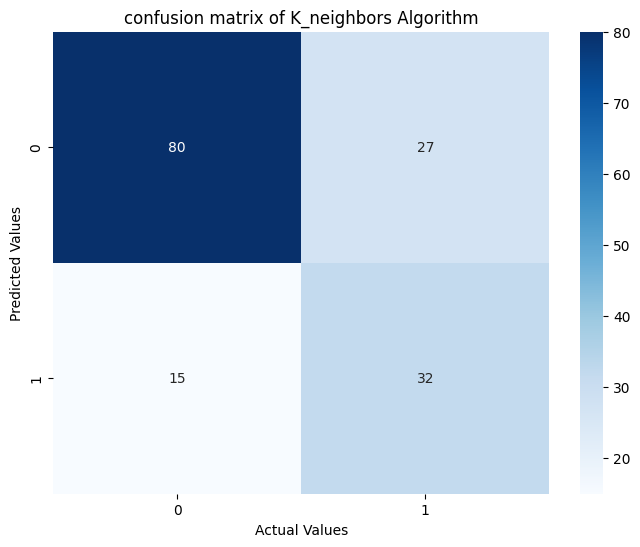

In [64]:
plt.figure(figsize = (8,6))
sns.heatmap(confusion_matrix(test_pred,y_test),annot=True,cmap="Blues")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("confusion matrix of K_neighbors Algorithm")
plt.show()

## Logistics Regression

In [65]:
scale = StandardScaler()

In [66]:
x_test_scale = scale.fit_transform(x_test)

In [67]:
test_pred = modelLR.predict(x_test_scale)

In [68]:
accuracy_score(test_pred,y_test)

0.7597402597402597

In [69]:
confusion_matrix(test_pred,y_test)

array([[87, 29],
       [ 8, 30]], dtype=int64)

In [70]:
classification_report(test_pred,y_test)

'              precision    recall  f1-score   support\n\n           0       0.92      0.75      0.82       116\n           1       0.51      0.79      0.62        38\n\n    accuracy                           0.76       154\n   macro avg       0.71      0.77      0.72       154\nweighted avg       0.82      0.76      0.77       154\n'

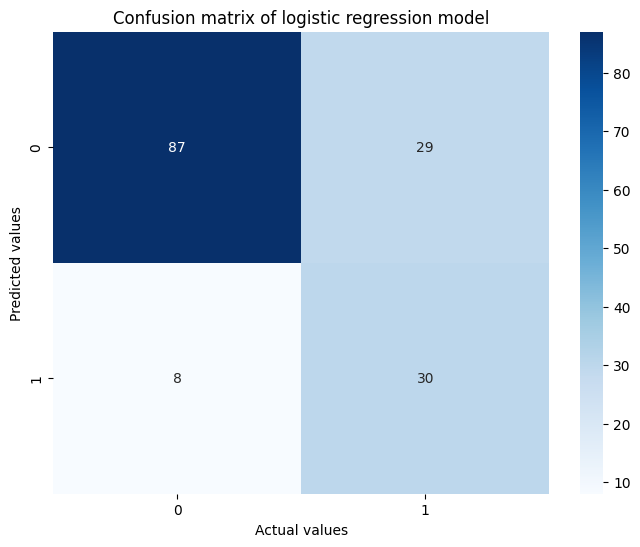

In [71]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(test_pred,y_test),annot=True,cmap="Blues")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Confusion matrix of logistic regression model")
plt.show()

## SVM

In [72]:
scale = StandardScaler()

In [73]:
x_test_scale = scale.fit_transform(x_test)

In [74]:
test_pred = modelSVM.predict(x_test_scale)

In [75]:
accuracy_score(test_pred,y_test)

0.7337662337662337

In [76]:
confusion_matrix(test_pred,y_test)

array([[84, 30],
       [11, 29]], dtype=int64)

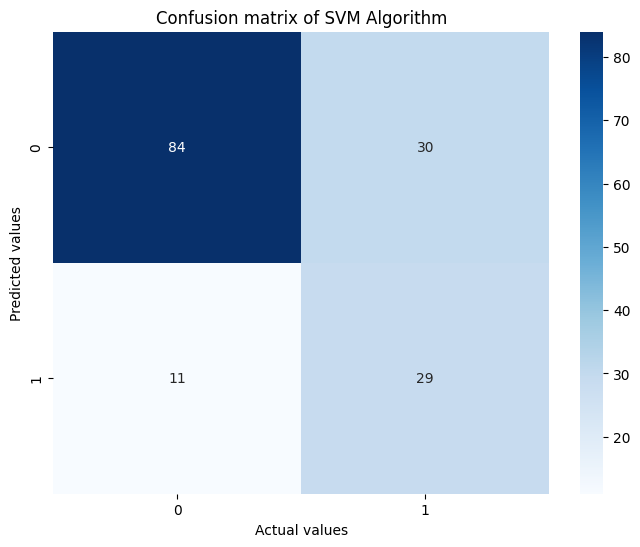

In [77]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(test_pred,y_test),annot=True,cmap="Blues")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Confusion matrix of SVM Algorithm")
plt.show()

## Rnadom Forest Classifier

In [78]:
test_pred = modelRF.predict(x_test)

In [79]:
accuracy_score(y_test,test_pred)

0.7662337662337663

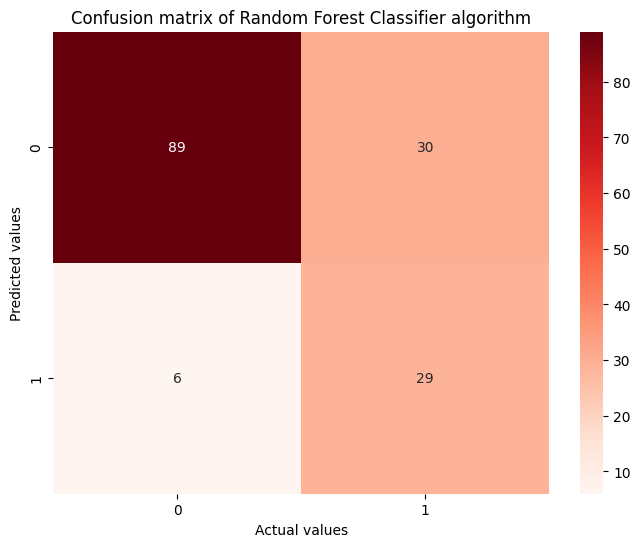

In [80]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(test_pred,y_test),annot=True,cmap="Reds")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Confusion matrix of Random Forest Classifier algorithm")
plt.show()

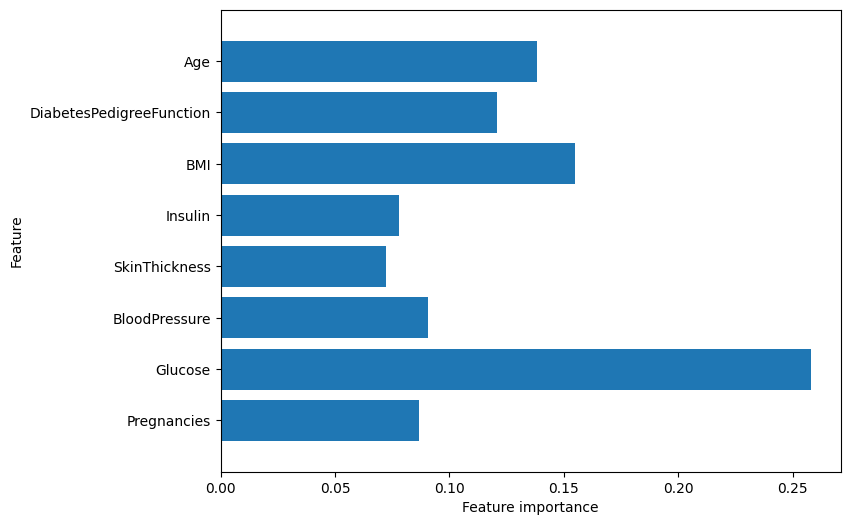

In [87]:
plt.figure(figsize=(8,6))
n_feature=8
plt.barh(range(n_feature),modelRF.feature_importances_,align="center")
diabetes_feature=[x for i ,x in enumerate(data.columns) if i != 8]
plt.yticks(np.arange(n_feature),diabetes_feature)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.ylim(-1,n_feature)
plt.show()